# Overview

We are now going to investigate how to calculate the Gibbs free energy of a periodic solid. This is a bit trickier mathematically, but the same process needs to take place: we must optimize the structure, get the energy, and then calculate the vibrational modes. In the case of solids, these vibrational modes are called phonons.

While ASE has builtin routines for calculating phonon modes of solids and the thermochemistry of solids (see `CrystalThermo`), there is a more powerful code called [phonopy](https://github.com/phonopy/phonopy) that is generally adopted in the community. Phonopy is a bit complicated to use, so we will rely on a package called [matcalc](https://github.com/materialyzeai/matcalc) that makes it a lot easier.

We will use `matcalc` extensively when we discuss machine learning interatomic potentials in greater detial.


# Setup


In [2]:
!uv pip install "git+https://github.com/materialyzeai/matcalc.git" "upet>=0.2.1"

Using Python 3.13.7 environment at: /Users/ct5868/personal/cbe423/.venv
Resolved 85 packages in 201ms                                        
Audited 85 packages in 1ms


We will use the UPET machine learning potential here since it's reasonably accurate and fast. It can be thought of as a drop-in replacement for DFT. We need to download the model checkpoint.


In [ ]:
!curl -L "https://huggingface.co/lab-cosmo/upet/resolve/main/models/pet-mad-s-v1.5.0.ckpt" -o pet-mad-s-v1.5.0.ckpt

In [3]:
from upet.calculator import UPETCalculator

calc = UPETCalculator(model="pet-mad-s", version="1.5.0")

/Users/ct5868/personal/cbe423/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Demonstration

We will calculate the Gibbs free energy of a 2x2x2 unit cell of Cu.


## Matcalc Overview


In [4]:
from ase.build import bulk

atoms = bulk("Cu") * (2, 2, 2)

First, let me introduce you to `matcalc` briefly. `matcalc` is basically a wrapper around ASE and some other utilities. You know those relaxations you have been carrying out in ASE? They can be carried out using `matcalc` too. Let's try that out.


In [5]:
from matcalc import RelaxCalc

relax = RelaxCalc(calc, optimizer="BFGS", fmax=0.01, relax_cell=True)

From the above example, it should hopefully be clear that this is basically just a streamlined interface to ASE. The benefit is somebody has taken care of figuring out what to do for you. The downside is means you have less control, and you must be very careful to make sure it is doing what you want it to do.

We call the `.calc()` method on an `Atoms` or `Structure` object to launch the calculation. There is also a `.calc_many()` option to parallelize calculations.


In [6]:
relax_result = relax.calc(atoms)

The result is a dictionary with various fields you can query by.


In [7]:
relax_result["energy"]

-34.509422302246094

In [8]:
relax_result["final_structure"]

Structure Summary
Lattice
    abc : 5.0553927162158026 5.05537924791346 5.055388062464574
 angles : 59.996221710667406 59.99122097808834 59.99931545601544
 volume : 91.34918363809606
      A : np.float64(0.0002524635904882563) np.float64(3.5749226966386463) np.float64(3.574482223272036)
      B : np.float64(3.5747757070503328) np.float64(0.0001245028449152042) np.float64(3.5746101842041313)
      C : np.float64(3.574561694630874) np.float64(3.574836645050267) np.float64(0.0003385154674597809)
    pbc : True True True
PeriodicSite: Cu (-6.302e-08, -6.625e-08, 1.692e-07) [2.322e-08, 2.412e-08, -4.175e-08]
PeriodicSite: Cu (1.787, 1.787, 0.0001693) [-4.551e-08, 4.899e-08, 0.5]
PeriodicSite: Cu (1.787, 6.225e-05, 1.787) [8.091e-09, 0.5, -7.628e-09]
PeriodicSite: Cu (3.575, 1.787, 1.787) [1.606e-08, 0.5, 0.5]
PeriodicSite: Cu (0.0001262, 1.787, 1.787) [0.5, 2.727e-08, -4.641e-08]
PeriodicSite: Cu (1.787, 3.575, 1.787) [0.5, 1.834e-08, 0.5]
PeriodicSite: Cu (1.788, 1.788, 3.575) [0.5, 0.5, 5

We can convert the Pymatgen `Structure` back to `Atoms` if we'd like. Don't worry that the return type is `MSONAtoms`; it is effectively the same thing as a normal `Atoms` object.


In [9]:
relax_result["final_structure"].to_ase_atoms()

MSONAtoms(symbols='Cu8', pbc=True, cell=[[0.0002524635904882563, 3.5749226966386463, 3.574482223272036], [3.5747757070503328, 0.0001245028449152042, 3.5746101842041313], [3.574561694630874, 3.574836645050267, 0.0003385154674597809]], calculator=UPETCalculator(...))

## Gibbs Free Energy


We have to relax the Cu structure and then carry out a phonon mode calculation to get the Gibbs free energy. Conveniently, `matcalc` provides a single function to do both, and it will calculate the Gibbs free energy for us too. It does this in the `QHACalc` class, which is the quasi-harmonic approximation (QHA) method.


In [10]:
from matcalc import QHACalc

qha = QHACalc(
    calc,
    t_min=0,  # K
    t_max=1000,  # K
    fmax=0.01,  # eV/A
    optimizer="BFGS",
    pressure=1e-4,  # GPa
    relax_structure=True,
)

In [11]:
result = qha.calc(atoms)

In [12]:
T_vals = result["temperatures"]
print(T_vals)

[   0   10   20   30   40   50   60   70   80   90  100  110  120  130
  140  150  160  170  180  190  200  210  220  230  240  250  260  270
  280  290  300  310  320  330  340  350  360  370  380  390  400  410
  420  430  440  450  460  470  480  490  500  510  520  530  540  550
  560  570  580  590  600  610  620  630  640  650  660  670  680  690
  700  710  720  730  740  750  760  770  780  790  800  810  820  830
  840  850  860  870  880  890  900  910  920  930  940  950  960  970
  980  990 1000]


In [13]:
G_vals = result["gibbs_free_energies"]
print(G_vals)

[-34.25419005 -34.25419342 -34.25424389 -34.25447934 -34.2551454
 -34.25652501 -34.25885944 -34.26231925 -34.26700828 -34.27297867
 -34.28024613 -34.2888022  -34.29862317 -34.30967618 -34.32192332
 -34.33532435 -34.34983838 -34.36542499 -34.38204488 -34.39966028
 -34.41823514 -34.43773519 -34.45812799 -34.47938288 -34.50147091
 -34.52436477 -34.54803865 -34.57246823 -34.59763053 -34.62350382
 -34.65006757 -34.67730232 -34.70518973 -34.73371228 -34.76285341
 -34.79259742 -34.82292931 -34.85383488 -34.88530056 -34.91731343
 -34.94986116 -34.98293195 -35.01651458 -35.05059827 -35.08517271
 -35.12022799 -35.15575475 -35.19174377 -35.22818645 -35.26507432
 -35.30239935 -35.34015384 -35.37833031 -35.41692151 -35.45592062
 -35.49532087 -35.53511594 -35.57529948 -35.61586559 -35.65680838
 -35.69812227 -35.73980192 -35.78184198 -35.8242374  -35.86698321
 -35.9100748  -35.95350743 -35.99727662 -36.04137805 -36.08580752
 -36.13056093 -36.17563432 -36.22102384 -36.26672569 -36.31273631
 -36.359052

Now we can plot G vs. T if we'd like. Note that there is an off-by-one indexing issue that [will be resolved](https://github.com/materialyzeai/matcalc/issues/150) later.


Text(0, 0.5, 'G (eV)')

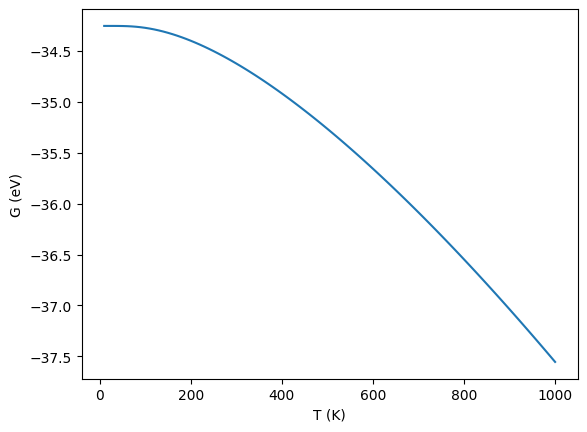

In [14]:
import matplotlib.pyplot as plt

plt.plot(T_vals[0:-1], G_vals)
plt.xlabel("T (K)")
plt.ylabel("G (eV)")